In [ ]:
# ===============================
#        PPMI DATASET
# ===============================

#load dataset
import pandas as pd
df=pd.read_csv('/content/PPMI_Biomarkers_Pivoted.csv')
df.isnull().sum()

,0
PATNO,0
SEX,0
COHORT,0
CLINICAL_EVENT,0
Abeta_42_pgml,3908
Abeta_42 1-42,3394
Abeta_42 raw,3908
Abeta_4240,6218
Abeta_4242,6218
bd tTau_Total,6153


In [ ]:
import pandas as pd
import numpy as np

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder

def clean_ppmi_data(input_file, output_file):
    # 1. Load the dataset
    df = pd.read_csv(input_file)

    # Defined identifier columns
    ids = ['PATNO', 'SEX', 'COHORT', 'CLINICAL_EVENT']
    biomarker_cols = [c for c in df.columns if c not in ids]

    # 2. Function to clean numeric columns
    def clean_numeric_values(val):
        if pd.isnull(val):
            return np.nan
        clean_str = str(val).split('(')[0].strip()
        if '<' in clean_str:
            try:
                return float(clean_str.replace('<', '')) / 2
            except:
                return np.nan
        try:
            return float(clean_str)
        except:
            return np.nan

    for col in biomarker_cols:
        df[col] = df[col].apply(clean_numeric_values)

    # 3. Drop columns with > 80% missing values
    missing_pct = df[biomarker_cols].isnull().mean()
    reliable_cols = missing_pct[missing_pct <= 0.80].index.tolist()

    print(f"Keeping reliable biomarkers: {reliable_cols}")
    df_clean = df[ids + reliable_cols].copy()

    # 4. Remove rows that have no biomarker measurements at all
    df_clean = df_clean.dropna(subset=reliable_cols, how='all')

    # ========================================================
    # 5. MICE (Iterative) Imputation
    # ========================================================
    # max_iter: number of imputation rounds to stabilize coefficients

    mice_imputer = IterativeImputer(max_iter=10, random_state=42, initial_strategy='mean')

    # Create a numeric helper for context
    df_impute = df_clean.copy()

    # Efficient encoding for SEX and COHORT
    df_impute['SEX'] = df_impute['SEX'].map({'Male': 0, 'Female': 1})
    df_impute['COHORT_CODE'] = pd.factorize(df_impute['COHORT'])[0]

    # Specify columns for imputation logic
    target_cols = ['SEX', 'COHORT_CODE'] + reliable_cols

    # Apply MICE
    # MICE will model each biomarker based on SEX, COHORT, and other biomarkers
    df_impute[target_cols] = mice_imputer.fit_transform(df_impute[target_cols])

    # Map the imputed values back to our clean dataframe
    df_clean[reliable_cols] = df_impute[reliable_cols]

    # 6. Save the final result
    df_clean.to_csv(output_file, index=False)
    print(f"Cleaned data saved to {output_file} using MICE imputation.")
    return df_clean

# Execute
cleaned_data = clean_ppmi_data('/content/PPMI_Biomarkers_Pivoted.csv', 'PPMI_Cleaned_Final.csv')
import pandas as pd
import numpy as np
# MICE requires enabling the experimental module
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# ===============================
# 1. LOAD & MERGE DATASETS
# ===============================
csf_df = pd.read_csv('/content/PPMI_Cleaned_Final.csv')
updrs2_df = pd.read_csv('/content/MDS_UPDRS_Part_II__Patient_Questionnaire_27Jan2026.csv')
moca_df = pd.read_csv('/content/Montreal_Cognitive_Assessment__MoCA__27Jan2026.csv')
updrs3_df = pd.read_csv('/content/MDS-UPDRS_Part_III_27Jan2026.csv')

# Subsetting and Renaming
updrs2_subset = updrs2_df[['PATNO', 'EVENT_ID', 'NP2PTOT']].rename(columns={'EVENT_ID': 'CLINICAL_EVENT', 'NP2PTOT': 'UPDRS_Part_II_Total'})
moca_subset = moca_df[['PATNO', 'EVENT_ID', 'MCATOT']].rename(columns={'EVENT_ID': 'CLINICAL_EVENT', 'MCATOT': 'MoCA_Total'})
updrs3_subset = updrs3_df[['PATNO', 'EVENT_ID', 'NP3TOT']].rename(columns={'EVENT_ID': 'CLINICAL_EVENT', 'NP3TOT': 'UPDRS_Part_III_Total'})

# Sequential Merging
merged_df = csf_df.merge(updrs2_subset, on=['PATNO', 'CLINICAL_EVENT'], how='left')
merged_df = merged_df.merge(moca_subset, on=['PATNO', 'CLINICAL_EVENT'], how='left')
merged_df = merged_df.merge(updrs3_subset, on=['PATNO', 'CLINICAL_EVENT'], how='left')

# Drop duplicates & Filter SWEDD (Scans Without Evidence of Dopaminergic Deficit)
merged_df = merged_df.drop_duplicates(subset=['PATNO', 'CLINICAL_EVENT'], keep='first')
merged_df = merged_df[merged_df['COHORT'] != 'SWEDD']

# ===============================
# 2. GROUP-AWARE MICE IMPUTATION
# ===============================
clinical_cols = ['MoCA_Total', 'UPDRS_Part_III_Total', 'UPDRS_Part_II_Total']
df_imputed = merged_df.copy()

print("Starting Group-Aware MICE Imputation...")

# We iterate by COHORT to ensure biological consistency
# (e.g., a missing UPDRS score for a PD patient is filled based on other PD patients)
for cohort in df_imputed['COHORT'].unique():
    mask = df_imputed['COHORT'] == cohort
    subset = df_imputed.loc[mask, clinical_cols]

    # Check if we have enough data to model relationships
    if subset.dropna().shape[0] < 10:
        continue

    # MICE Imputer logic
    # initial_strategy='median' is safer for skewed clinical scores
    mice_imputer = IterativeImputer(max_iter=10, random_state=42, initial_strategy='median')

    df_imputed.loc[mask, clinical_cols] = mice_imputer.fit_transform(subset)

merged_df = df_imputed
print("Imputation Complete. Missing values remaining:\n", merged_df[clinical_cols].isnull().sum())

# ===============================
# 3. BIO-RATIO ENGINEERING
# ===============================
eps = 1e-6

# Indices for Cognitive Health, Neurodegeneration, and Parkinson's pathology
merged_df['Ratio_Abeta_pTau'] = merged_df['Abeta_42_pgml'] / (merged_df['pTau_Total'] + eps)
merged_df['Ratio_Abeta_tTau'] = merged_df['Abeta_42_pgml'] / (merged_df['tTau_Total'] + eps)
merged_df['Ratio_pTau_tTau'] = merged_df['pTau_Total'] / (merged_df['tTau_Total'] + eps)
merged_df['Ratio_tTau_ASyn'] = merged_df['tTau_Total'] / (merged_df['csf Alpha_Synuclein'] + eps)

# Clipping Outliers (99th Percentile) to prevent ratio explosion in the model
ratio_cols = ['Ratio_Abeta_pTau', 'Ratio_Abeta_tTau', 'Ratio_pTau_tTau', 'Ratio_tTau_ASyn']
for col in ratio_cols:
    merged_df[col] = merged_df[col].clip(upper=merged_df[col].quantile(0.99))

# ===============================
# 4. SAVE FINAL MERGED PRODUCT
# ===============================
merged_df.to_csv('PPMI_Merged_Clinical_CSF_Final.csv', index=False)
print("Merge and MICE processing complete! Final shape:", merged_df.shape)

Keeping reliable biomarkers: ['Abeta_42_pgml', 'Abeta_42 1-42', 'Abeta_42 raw', 'csf Alpha_Synuclein', 'pTau_Total', 'pTau_Total217p', 'tTau_Total']


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Cleaned data saved to PPMI_Cleaned_Final.csv using MICE imputation.


/tmp/ipython-input-725381986.py:87: DtypeWarning: Columns (16,21) have mixed types. Specify dtype option on import or set low_memory=False.
  updrs3_df = pd.read_csv('/content/MDS-UPDRS_Part_III_27Jan2026.csv')


Starting Group-Aware MICE Imputation...
Imputation Complete. Missing values remaining:
 MoCA_Total              0
UPDRS_Part_III_Total    0
UPDRS_Part_II_Total     0
dtype: int64
Merge and MICE processing complete! Final shape: (6115, 18)


In [ ]:
merged_df=df_imputed
merged_df.value_counts('COHORT')
merged_df = merged_df[merged_df['COHORT'] != 'SWEDD']
merged_df.value_counts('COHORT')


,count
COHORT,
PD,3127
Prodromal,1945
Control,1043


In [ ]:
eps = 1e-6  # Prevent division by zero & ratio explosion

# 1. Abeta to Phosphorylated Tau (Cognitive health index)
merged_df['Ratio_Abeta_pTau'] = merged_df['Abeta_42_pgml'] / (merged_df['pTau_Total'] + eps)

# 2. Abeta to Total Tau (Neurodegeneration index)
merged_df['Ratio_Abeta_tTau'] = merged_df['Abeta_42_pgml'] / (merged_df['tTau_Total'] + eps)

# 3. pTau to Total Tau (Tau specificity index)
merged_df['Ratio_pTau_tTau'] = merged_df['pTau_Total'] / (merged_df['tTau_Total'] + eps)

# 4. Tau to Alpha-Synuclein (Parkinson’s-related index)
merged_df['Ratio_tTau_ASyn'] = merged_df['tTau_Total'] / (merged_df['csf Alpha_Synuclein'] + eps) # Corrected column name


ratio_cols = [
    'Ratio_Abeta_pTau',
    'Ratio_Abeta_tTau',
    'Ratio_pTau_tTau',
    'Ratio_tTau_ASyn'
]
#outlier handling
for col in ratio_cols:
    merged_df[col] = merged_df[col].clip(upper=merged_df[col].quantile(0.99))
merged_df.isnull().sum()

,0
PATNO,0
SEX,0
COHORT,0
CLINICAL_EVENT,0
Abeta_42_pgml,0
Abeta_42 1-42,0
Abeta_42 raw,0
csf Alpha_Synuclein,0
pTau_Total,0
pTau_Total217p,0


Class Counts:
COHORT
PD           3127
Prodromal    1945
Control      1043
Name: count, dtype: int64

Percentage Distribution:
COHORT
PD           51.136549
Prodromal    31.807032
Control      17.056419
Name: proportion, dtype: float64


/tmp/ipython-input-3576344790.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='COHORT', data=df, palette='viridis', order=df['COHORT'].value_counts().index)


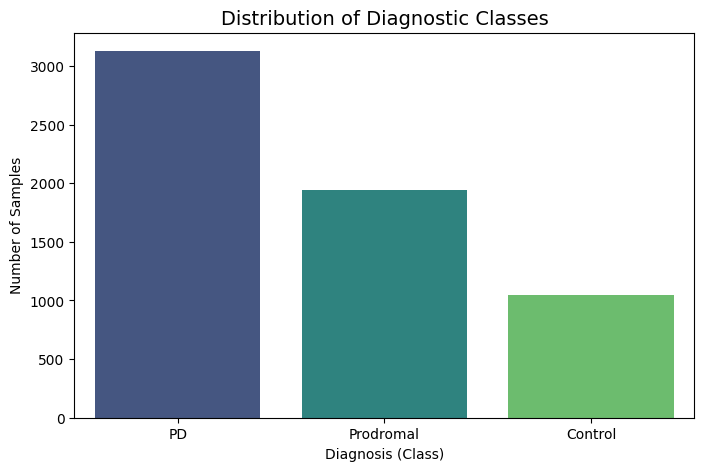

In [ ]:
df=merged_df
print("Class Counts:")
counts = df['COHORT'].value_counts()
print(counts)

# Check the percentage distribution
print("\nPercentage Distribution:")
print(df['COHORT'].value_counts(normalize=True) * 100)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x='COHORT', data=df, palette='viridis', order=df['COHORT'].value_counts().index)
plt.title('Distribution of Diagnostic Classes', fontsize=14)
plt.ylabel('Number of Samples')
plt.xlabel('Diagnosis (Class)')
plt.show()

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00



--- 5-Fold GroupCV Performance ---
Accuracy           : 0.8612
Balanced Accuracy  : 0.8156
F1 Macro           : 0.8195


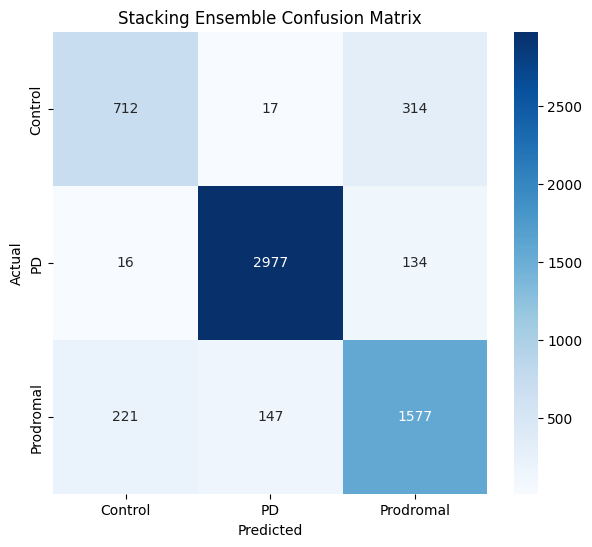


--- Classification Report ---
              precision    recall  f1-score   support

     Control       0.75      0.68      0.71      1043
          PD       0.95      0.95      0.95      3127
   Prodromal       0.78      0.81      0.79      1945

    accuracy                           0.86      6115
   macro avg       0.83      0.82      0.82      6115
weighted avg       0.86      0.86      0.86      6115


--- Sensitivity & Specificity ---

Class: Control
Sensitivity (Recall): 0.6826
Specificity         : 0.9533

Class: PD
Sensitivity (Recall): 0.9520
Specificity         : 0.9451

Class: Prodromal
Sensitivity (Recall): 0.8108
Specificity         : 0.8926


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
features = [
    'Abeta_42_pgml', 'pTau_Total', 'tTau_Total', 'csf Alpha_Synuclein',
    'UPDRS_Part_II_Total', 'MoCA_Total', 'UPDRS_Part_III_Total',
    'Ratio_Abeta_pTau', 'Ratio_Abeta_tTau', 'Ratio_pTau_tTau', 'Ratio_tTau_ASyn'
]

# 2. Define X, y, and groups
X = merged_df[features]
y = merged_df['COHORT']
groups = merged_df['PATNO']
# ===============================
# 2. LABEL ENCODING
# ===============================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ===============================
# 3. LIGHTER BASE MODELS (FASTER)
# ===============================

rf = RandomForestClassifier(
    n_estimators=120,
    n_jobs=-1,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42
)



cat = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

# ===============================
# 4. STACKING MODEL
# ===============================

stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('cat',cat),

    ],
    final_estimator=LogisticRegression(max_iter=1000),
    n_jobs=-1
)

pipeline = ImbPipeline(steps=[
    ('smote_tomek', SMOTETomek(random_state=42)),
    ('stacking', stack_model)
])
# ===============================
# 5. SINGLE GROUP-KFOLD LOOP
# ===============================

gkf = GroupKFold(n_splits=5)

all_true = []
all_pred = []

acc_scores = []
bal_acc_scores = []
f1_scores = []

for train_idx, test_idx in gkf.split(X, y_encoded, groups):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    # Store predictions
    all_true.extend(y_test)
    all_pred.extend(preds)

    # Fold metrics
    acc_scores.append(accuracy_score(y_test, preds))
    bal_acc_scores.append(balanced_accuracy_score(y_test, preds))
    f1_scores.append(f1_score(y_test, preds, average='macro'))

# ===============================
# 6. CROSS-VALIDATED METRICS
# ===============================

print("\n--- 5-Fold GroupCV Performance ---")
print(f"Accuracy           : {np.mean(acc_scores):.4f}")
print(f"Balanced Accuracy  : {np.mean(bal_acc_scores):.4f}")
print(f"F1 Macro           : {np.mean(f1_scores):.4f}")

# ===============================
# 7. CONFUSION MATRIX
# ===============================

cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacking Ensemble Confusion Matrix")
plt.show()

# ===============================
# 8. CLASSIFICATION REPORT
# ===============================

print("\n--- Classification Report ---")
print(classification_report(
    le.inverse_transform(all_true),
    le.inverse_transform(all_pred)
))

# ===============================
# 9. SENSITIVITY & SPECIFICITY
# ===============================

print("\n--- Sensitivity & Specificity ---")

n_classes = cm.shape[0]

for i in range(n_classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    print(f"\nClass: {le.classes_[i]}")
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity         : {specificity:.4f}")

